In [56]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.metrics import brier_score_loss
from sklearn.impute import KNNImputer, SimpleImputer
from imblearn.under_sampling import NearMiss 
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
import sys
import shap
import math
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, plot_imbalance_vertical, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve, binary_entropy, yearCV_split
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'

file1 = r'E:\Drive\NOA\MBD-Prediction\GRID Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'

dataset = read_data(file1)

dataset.head()

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(664560, 92)


In [57]:
dataset.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [58]:
len(dataset.cell_code.unique())

4260

In [59]:
dataset = encode_cyclical(dataset, 'month', 12)

In [60]:
dataset.cases.sum()

1364

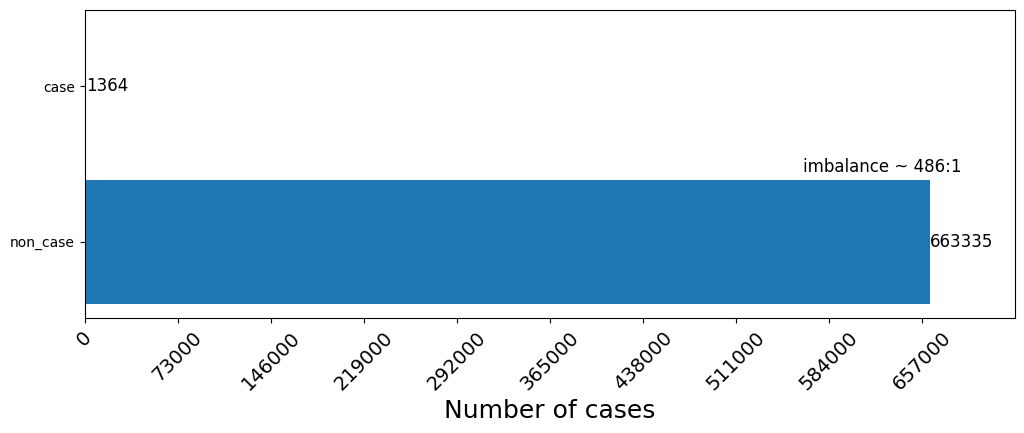

In [61]:
plot_imbalance(dataset, target_column='cases')

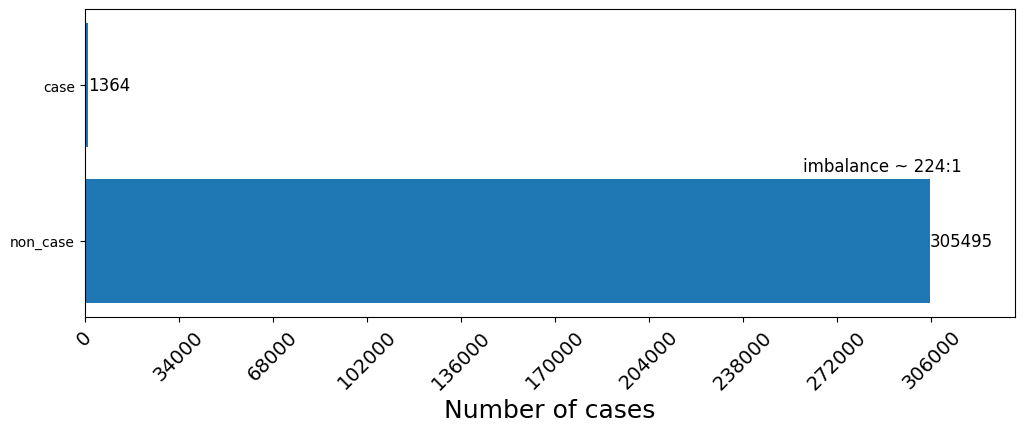

In [62]:
dataset = dataset.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

In [63]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

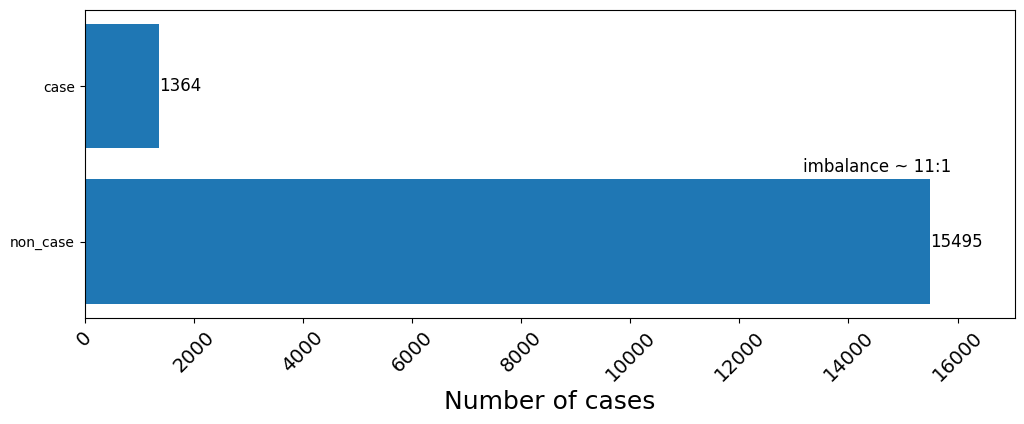

In [64]:
rows_to_remove = dataset.query('cases == 0').sample(n=290000, random_state=0).index
# rows_to_remove = dataset.query('cases == 0').sample(n=290000, random_state=0).index
# rows_to_remove = dataset.query('cases == 0').sample(n=280000, random_state=0).index
# rows_to_remove = dataset.query('cases == 0').sample(n=150000, random_state=0).index

dataset.drop(rows_to_remove, inplace=True)
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

In [65]:
dataset.shape

(16720, 94)

In [66]:
dataset.cases.sum()

1364

In [67]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1299,262,1561,4.96%
1,2011,1268,100,1368,12.68%
2,2012,1281,157,1438,8.16%
3,2013,1307,85,1392,15.38%
4,2014,1242,15,1257,82.80%
5,2015,1339,0,1339,inf%
6,2016,1300,0,1300,inf%
7,2017,1233,42,1275,29.36%
8,2018,1243,296,1539,4.20%
9,2019,1325,218,1543,6.08%


In [68]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [69]:
#features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove = ['year', 'month',
                      'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
#features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'month_sin', 'month_cos']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_tot

In [70]:
print(feature_names)

Index(['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max',
       'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3',
       'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11',
       'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_1

In [71]:
weights = pd.Series(y.clip(lower=1).values, name = 'weights')

weights_new = np.ceil(weights / 1).astype(int)

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
import numpy as np
import pandas as pd

years = [2019, 2020, 2021]

param_grid = {
    "learning_rate": [0.03, 0.05],
    "n_estimators": [200, 300],
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5],
    "gamma": [0, 1.0],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "reg_alpha": [0, 1.0],
    "reg_lambda": [3.0, 5.0],
}

all_results = []
best_score = -np.inf
best_params = None

for grid_params in ParameterGrid(param_grid):
    fold_scores = []
    y_true_all = []
    y_proba_all = []

    print(f"\nTesting params: {grid_params}")

    for test_year in years:
        train_idx = dataset.index[dataset["year"] < test_year].tolist()
        test_idx = dataset.index[dataset["year"] == test_year].tolist()

        data_train = dataset.iloc[train_idx].copy()
        data_test = dataset.iloc[test_idx].copy()
        weights_train = weights_new.iloc[train_idx].copy()

        data_train["cases"] = (data_train["cases"] > 0).astype(int)
        data_test["cases"] = (data_test["cases"] > 0).astype(int)

        data_train.reset_index(inplace=True, drop=True)
        data_test.reset_index(inplace=True, drop=True)
        weights_train = weights_train.reset_index(drop=True)

        y_train = data_train["cases"]
        y_test = data_test["cases"]

        sum_negatives = (y_train == 0).sum()
        sum_positives = (y_train == 1).sum()

        X_train = data_train.select_dtypes(exclude=["object"]).drop(
            columns=features_to_remove + ["cases"]
        )
        X_test = data_test.select_dtypes(exclude=["object"]).drop(
            columns=features_to_remove + ["cases"]
        )

        imputer = SimpleImputer()
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)

        params = {
            "objective": "binary:logistic",
            "device": "gpu",
            "eval_metric": "logloss",
            "scale_pos_weight": sum_negatives / sum_positives,
            "random_state": 42,
            **grid_params,
        }

        model = xgb.XGBClassifier(**params)
        model.fit(X_train_imputed, y_train, sample_weight=weights_train)

        y_test_proba = model.predict_proba(X_test_imputed)[:, 1]

        fold_ap = average_precision_score(y_test, y_test_proba)
        fold_scores.append(fold_ap)

        y_true_all.append(y_test.to_numpy())
        y_proba_all.append(y_test_proba)

    y_true_all = np.concatenate(y_true_all)
    y_proba_all = np.concatenate(y_proba_all)

    pooled_ap = average_precision_score(y_true_all, y_proba_all)
    mean_fold_ap = np.mean(fold_scores)

    result = {
        **grid_params,
        "mean_fold_ap": mean_fold_ap,
        "pooled_ap": pooled_ap,
    }
    all_results.append(result)

    print(f"Mean fold AP: {mean_fold_ap:.4f} | Pooled AP: {pooled_ap:.4f}")

    if pooled_ap > best_score:
        best_score = pooled_ap
        best_params = result.copy()

results_df = pd.DataFrame(all_results).sort_values("pooled_ap", ascending=False).reset_index(drop=True)

print("\nBest params:")
print(best_params)

print("\nTop 10:")
print(results_df.head(10))


Testing params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 3.0, 'subsample': 0.7}
Mean fold AP: 0.3870 | Pooled AP: 0.3219

Testing params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 3.0, 'subsample': 0.8}
Mean fold AP: 0.3701 | Pooled AP: 0.3099

Testing params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 5.0, 'subsample': 0.7}


KeyboardInterrupt: 

In [104]:
results_df.iloc[0]

colsample_bytree      0.700000
gamma                 0.000000
learning_rate         0.050000
max_depth             2.000000
min_child_weight      5.000000
n_estimators        300.000000
reg_alpha             0.000000
reg_lambda            3.000000
subsample             0.700000
mean_fold_ap          0.427995
pooled_ap             0.351033
Name: 0, dtype: float64

In [72]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

years = [2019, 2020, 2021]

for test_year in years:
    train_idx = dataset.index[dataset["year"] < test_year].tolist()
    test_idx = dataset.index[dataset["year"] == test_year].tolist()

    print(f"Train: 2010-{test_year-1} | Test: {test_year}")
    print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

    data_train = dataset.iloc[train_idx].copy()
    data_test = dataset.iloc[test_idx].copy()
    weights_train = weights_new.iloc[train_idx].copy()

    data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu",
        "eval_metric": "logloss",
         "learning_rate": 0.05,
        "n_estimators": 300,
        "max_depth": 2,
        "min_child_weight": 5,
        "gamma": 0,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0,
        "reg_lambda": 3.0,
        "scale_pos_weight": sum_negatives / sum_positives,
        "random_state": 42,
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Test set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
        
    imputer = SimpleImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = xgb.XGBClassifier(**params)  

    trained_model = model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    # calibrated_model = CalibratedClassifierCV(model,method="isotonic",cv=3)

    # trained_model = calibrated_model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Training set 0/1 Ratio: 13.70
Test set 0/1 Ratio: 13.70
Weight: 13.70
Train: 2010-2019 | Test: 2020
Train size: 13879 | Test size: 1515
Training set 0/1 Ratio: 12.32
Test set 0/1 Ratio: 12.32
Weight: 12.32
Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326
Training set 0/1 Ratio: 12.12
Test set 0/1 Ratio: 12.12
Weight: 12.12


In [73]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true})

In [74]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.3015
Test Loss: 0.3083


In [75]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 1, round_factor = 2)
print(classification_thresholds)

thr = classification_thresholds

0.48


In [76]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.95      0.86      0.91      3983
           1       0.28      0.56      0.38       385

    accuracy                           0.84      4368
   macro avg       0.62      0.71      0.64      4368
weighted avg       0.89      0.84      0.86      4368



In [77]:
brier = brier_score_loss(y_test_true, y_test_proba[:,1])

print("Brier score:", brier)

Brier score: 0.10125666295571062


In [78]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[3433  550]
 [ 168  217]]


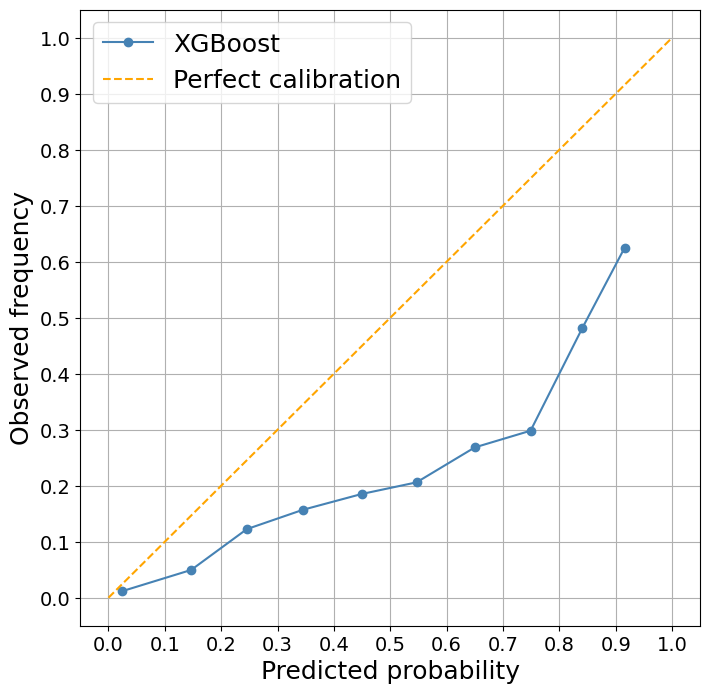

In [79]:
tick_size = 14
label_size = 18
legend_size = 18
text_size = 18

prob_true, prob_pred = calibration_curve(
    y_test_true,
    y_test_proba[:,1],
    n_bins=10,
    strategy="uniform"
)

plt.subplots(1, figsize=(8,8))

plt.plot(prob_pred, prob_true, marker="o", color = 'steelblue', label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--", color = 'orange', label="Perfect calibration")

plt.xlabel("Predicted probability", size=label_size)
plt.ylabel("Observed frequency", size=label_size)
plt.yticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.xticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.legend(prop={'size': legend_size})
plt.grid(True)
plt.show()

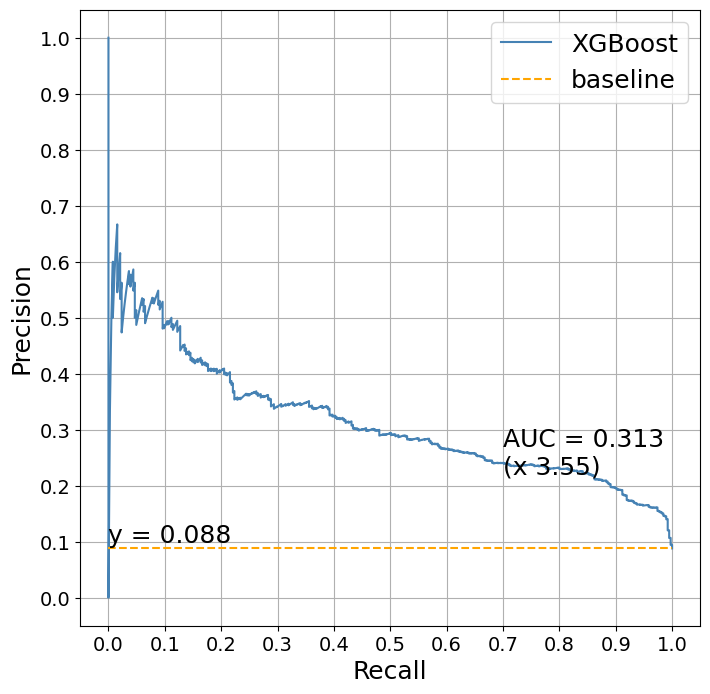

(0.8416, 0.23, 0.5447, 0.23)

In [80]:
plot_pr_curve(df_test, target_col = 'target', model_name='XGBoost', plot_fbeta=False, beta = 2)


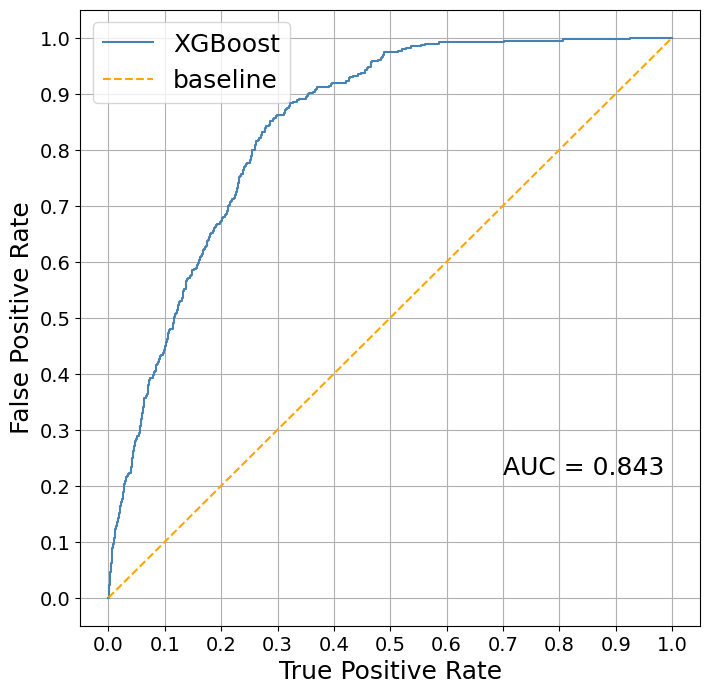

(0.2875, 0.8519, 0.7791, 0.2248)

In [81]:
plot_roc_curve(df_test, target_col = 'target', model_name='XGBoost')


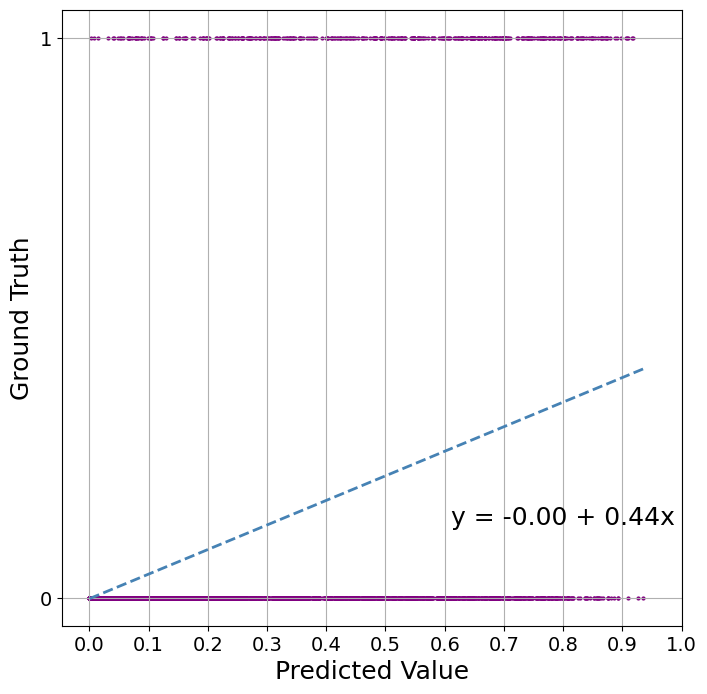

(-0.0017881991682994467, 0.43886117503899197)

In [82]:
plot_probability_curve(df_test, target_col = 'target', marker_size=4, x_label = 'Predicted Value', marker_shape='o')

In [29]:
n_ensembles = 10
n_folds = 10

# Store all predictions and ground truth
all_y_test = []
all_y_test_prob = []
all_test_indices = []

years = [2019, 2020, 2021]

# Ensemble loop
for ensemble_id in range(n_ensembles):
    print(f"\n=== Ensemble {ensemble_id + 1}/{n_ensembles} ===\n")

    for test_year in years:
        train_idx = dataset.index[dataset["year"] < test_year].tolist()
        test_idx = dataset.index[dataset["year"] == test_year].tolist()

        print(f"Train: 2010-{test_year-1} | Test: {test_year}")
        print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

        data_train = dataset.iloc[train_idx]
        data_test = dataset.iloc[test_idx]
        weights_train = weights_new.iloc[train_idx]

        data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
        data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

        data_train.reset_index(inplace = True, drop = True)
        data_test.reset_index(inplace = True, drop = True)

        sum_negatives = data_train['cases'].value_counts().get(0)
        sum_positives = data_train['cases'].value_counts().get(1)

        params = {
            "seed": ensemble_id * 100 + fold_counter,  # unique seed per model
            "objective": "binary:logistic",
            "device": "gpu",
            "eval_metric": "logloss",
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": 2,
            "min_child_weight": 5,
            "gamma": 0,
            "subsample": 0.7,
            "colsample_bytree": 0.7,
            "reg_alpha": 0,
            "reg_lambda": 3.0,
            "scale_pos_weight": sum_negatives / sum_positives,
        }

        X_train = data_train.select_dtypes(exclude=['object']).drop(columns=features_to_remove + ['cases'])
        X_test = data_test.select_dtypes(exclude=['object']).drop(columns=features_to_remove + ['cases'])

        y_train = data_train['cases']
        y_test = data_test['cases']

        imputer = SimpleImputer()
        imputer.fit(X_train)
        X_train_imputed = imputer.transform(X_train)
        X_test_imputed = imputer.transform(X_test)

        model = xgb.XGBClassifier(**params)  

        #calibrated_model = CalibratedClassifierCV(model,method="isotonic",cv=3)

        trained_model = model.fit(X_train_imputed, y_train, sample_weight = weights_train)

        y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1]

        # Save results (append fold-wise ground truth and probs)
        all_y_test.append(y_test.values)
        all_y_test_prob.append(y_test_prob)
        all_test_indices.append(test_idx)

        fold_counter += 1


=== Ensemble 1/10 ===

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Train: 2010-2019 | Test: 2020
Train size: 13879 | Test size: 1515
Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326

=== Ensemble 2/10 ===

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Train: 2010-2019 | Test: 2020
Train size: 13879 | Test size: 1515
Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326

=== Ensemble 3/10 ===

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Train: 2010-2019 | Test: 2020
Train size: 13879 | Test size: 1515
Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326

=== Ensemble 4/10 ===

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Train: 2010-2019 | Test: 2020
Train size: 13879 | Test size: 1515
Train: 2010-2020 | Test: 2021
Train size: 15394 | Test size: 1326

=== Ensemble 5/10 ===

Train: 2010-2018 | Test: 2019
Train size: 12352 | Test size: 1527
Train: 2010-2019 | Tes

In [30]:
all_preds = []

for model_id, (indices, probs) in enumerate(zip(all_test_indices, all_y_test_prob)):
    df = pd.DataFrame({
        'index': indices,
        'prob': probs,
        'model_id': model_id
    })
    all_preds.append(df)

# Combine all predictions
pred_df = pd.concat(all_preds, ignore_index=True)

# Group by sample index and compute mean and std
agg_df = pred_df.groupby("index")["prob"].agg(['mean', 'median', 'std']).reset_index()
agg_df.columns = ['index', 'mean_prob', 'median_prob', 'std_prob']

In [31]:
truth_data = []

for model_id, (indices, y_true) in enumerate(zip(all_test_indices, all_y_test)):
    df = pd.DataFrame({
        "index": indices,
        "y_true": y_true
    })
    truth_data.append(df)

# Combine and drop duplicates to keep one true label per sample index
truth_df = pd.concat(truth_data, ignore_index=True).drop_duplicates(subset="index")

In [32]:
agg_df_full = agg_df.merge(truth_df, on="index", how="left")

In [33]:
agg_df_full['entropy'] = binary_entropy(agg_df_full['mean_prob'].values)

In [34]:
agg_df_full

,index,mean_prob,median_prob,std_prob,y_true,entropy
0,12352,0.005854,0.005594,0.001159,0,0.035931
1,12353,0.008926,0.009037,0.001884,0,0.051007
2,12354,0.000376,0.000358,0.000095,0,0.003341
3,12355,0.001391,0.001373,0.000366,0,0.010537
4,12356,0.003807,0.003568,0.001003,0,0.025006
...,...,...,...,...,...,...
4363,16715,0.011688,0.011990,0.002865,0,0.063624
4364,16716,0.024784,0.024795,0.005775,0,0.116114
4365,16717,0.011306,0.010969,0.002873,0,0.061922
4366,16718,0.017834,0.018459,0.003755,0,0.089486


In [35]:
agg_df_full_sorted = agg_df_full.sort_values(by='mean_prob').reset_index(drop=True)

In [36]:
agg_df_full_sorted.shape[0]

4368

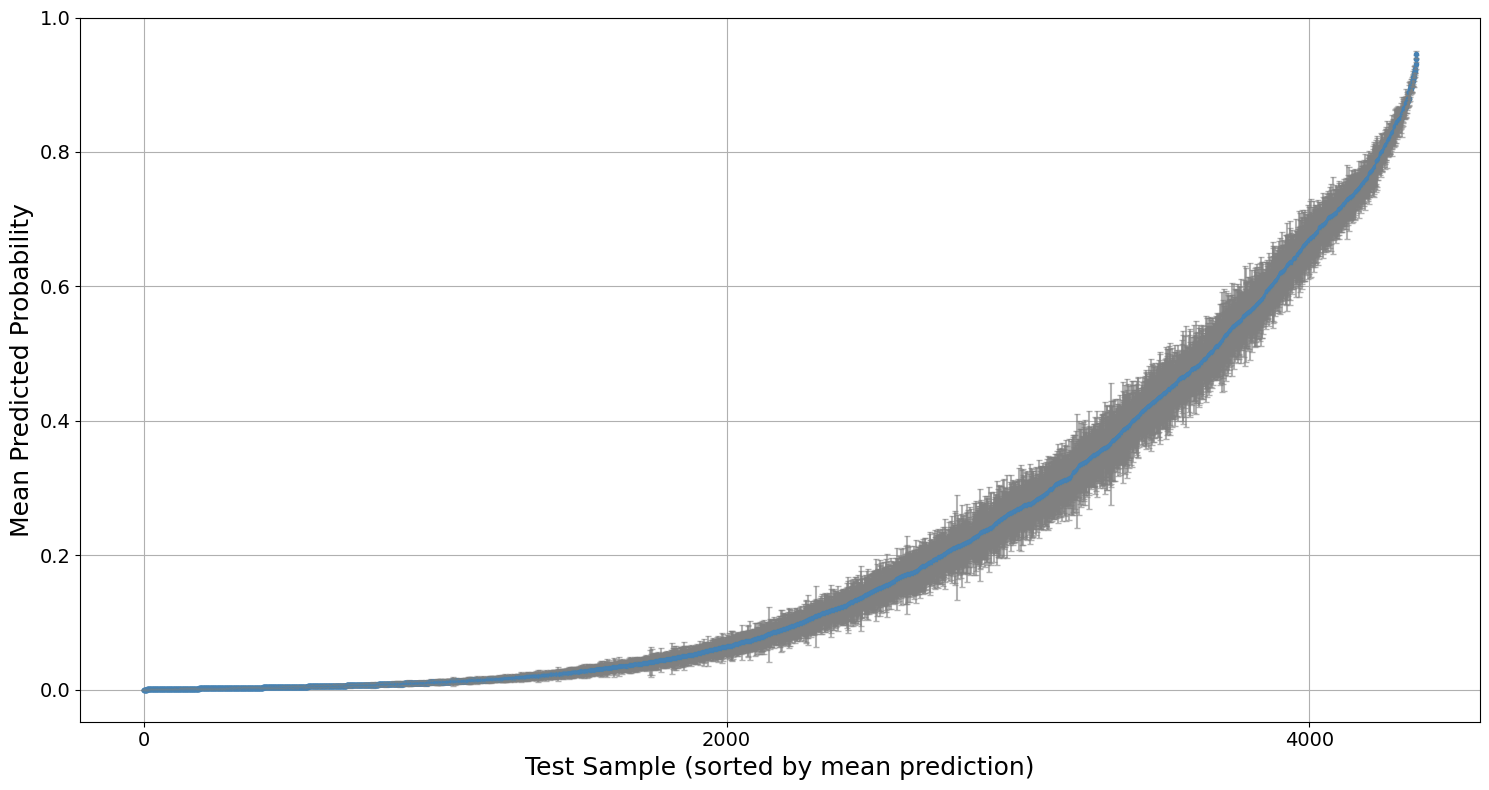

In [37]:
label_size = 18 
tick_size = 14
y_ticks_max = agg_df_full_sorted.shape[0]

plt.figure(figsize=(15, 8))

# Loop through each sample
for i in range(len(agg_df_full_sorted)):
    mean = agg_df_full_sorted['mean_prob'].iloc[i]
    std = agg_df_full_sorted['std_prob'].iloc[i]
    
    err_color = 'orange' if std > 0.10 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Test Sample (sorted by mean prediction)", size=label_size)
plt.ylabel("Mean Predicted Probability", size=label_size)
plt.yticks(np.arange(0, 1.1, step=0.2), size=tick_size)
plt.xticks(np.arange(0, round(y_ticks_max * 1.05, -2), step=2000), size=tick_size)
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.plot(fpr, tpr, color = 'steelblue', label = model_name)
# plt.plot([0, 1],  color = 'orange', ls="--", label = 'baseline')
# plt.plot(optimal_fpr, optimal_tpr, marker='o', markersize = 10, color = 'red', label = f'threshold = {optimal_threshold_roc:.2f}')


In [38]:
num_high_uncertainty = agg_df_full[agg_df_full['std_prob'] >= 0.10].shape[0]
total_samples = agg_df_full.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

0.0

In [39]:
print(f"Average Uncertainty of Predictions: {agg_df_full['std_prob'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {agg_df_full[agg_df_full['mean_prob'] >= thr]['std_prob'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {agg_df_full[agg_df_full['mean_prob'] < thr]['std_prob'].mean():.4f}")

Average Uncertainty of Predictions: 0.0192
High-risk Uncertainty of Predictions: 0.0337
Low-risk Uncertainty of Predictions: 0.0160


In [40]:
print(f"Average Entropy of Predictions: {agg_df_full['entropy'].mean():.4f}")
print(f"High-risk Entropy of Predictions: {agg_df_full[agg_df_full['mean_prob'] >= thr]['entropy'].mean():.4f}")
print(f"Low-risk Entropy of Predictions: {agg_df_full[agg_df_full['mean_prob'] < thr]['entropy'].mean():.4f}")

Average Entropy of Predictions: 0.3270
High-risk Entropy of Predictions: 0.6077
Low-risk Entropy of Predictions: 0.2660


In [41]:
print(f"Average Predictive Entropy: {agg_df_full['entropy'].mean():.4f}")
print(f"Average Std Dev of Predictions: {agg_df_full['std_prob'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Entropy:\n{agg_df_full.sort_values(by='entropy', ascending=False).head()}")
print(f"Top 5 Most Uncertain Samples by Std Dev:\n{agg_df_full.sort_values(by='std_prob', ascending=False).head()}")

Average Predictive Entropy: 0.3270
Average Std Dev of Predictions: 0.0192
Top 5 Most Uncertain Samples by Entropy:
      index  mean_prob  median_prob  std_prob  y_true   entropy
556   12908   0.500165     0.512903  0.049721       0  0.693147
3963  16315   0.500444     0.494974  0.040498       0  0.693147
3972  16324   0.499106     0.504043  0.054754       0  0.693146
4143  16495   0.498850     0.496174  0.039874       0  0.693145
3561  15913   0.501208     0.498939  0.012266       0  0.693144
Top 5 Most Uncertain Samples by Std Dev:
      index  mean_prob  median_prob  std_prob  y_true   entropy
1147  13499   0.365357     0.327791  0.090828       0  0.656438
1079  13431   0.325587     0.311062  0.085279       1  0.631009
2836  15188   0.211617     0.198704  0.078139       0  0.516091
854   13206   0.520972     0.508675  0.075956       0  0.692267
2561  14913   0.383165     0.395431  0.075157       0  0.665592


In [42]:
print(f"Mean of std of the top 20% worst examples {agg_df_full.sort_values(by='std_prob', ascending=False).iloc[:math.ceil(agg_df.shape[0]*0.2)].std_prob.mean():.4f}")
print(f"Std of std of the top 20% worst examples {agg_df_full.sort_values(by='std_prob', ascending=False).iloc[:math.ceil(agg_df.shape[0]*0.2)].std_prob.std():.4f}")

Mean of std of the top 20% worst examples 0.0465
Std of std of the top 20% worst examples 0.0086


In [43]:
data_train_shap = dataset.copy()

weights = pd.Series(data_train_shap['cases'].clip(lower=1).values, name = 'weights')
weights_new = np.ceil(weights / 1).astype(int)
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

# sum_negatives = data_train_shap['cases'].value_counts().get(0)
# sum_positives = data_train_shap['cases'].value_counts().get(1)

# scaler = MinMaxScaler(feature_range = (-1, 1))
# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

imputer = SimpleImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [44]:
# Tree explainer

# curently not working with multioutput models

# params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)  

trained_model = model.fit(X_train_imputed, y_train, sample_weight = weights_new)

tree_explainer = shap.TreeExplainer(trained_model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [45]:
num_of_location_cols = 8

location_columns = data_train_shap.iloc[:, :num_of_location_cols]
wnv_columns = data_train_shap['cases']

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

tree_shap_values_df

# region_attica = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30'))
# region_macedonia = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52'))
# region_thrace = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL51'))
# region_thessaly = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL61'))

# shap_values_df_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].to_numpy()
# shap_values_df_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].to_numpy()
# shap_values_df_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].to_numpy()
# shap_values_df_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].to_numpy()

sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, num_of_location_cols:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

In [46]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

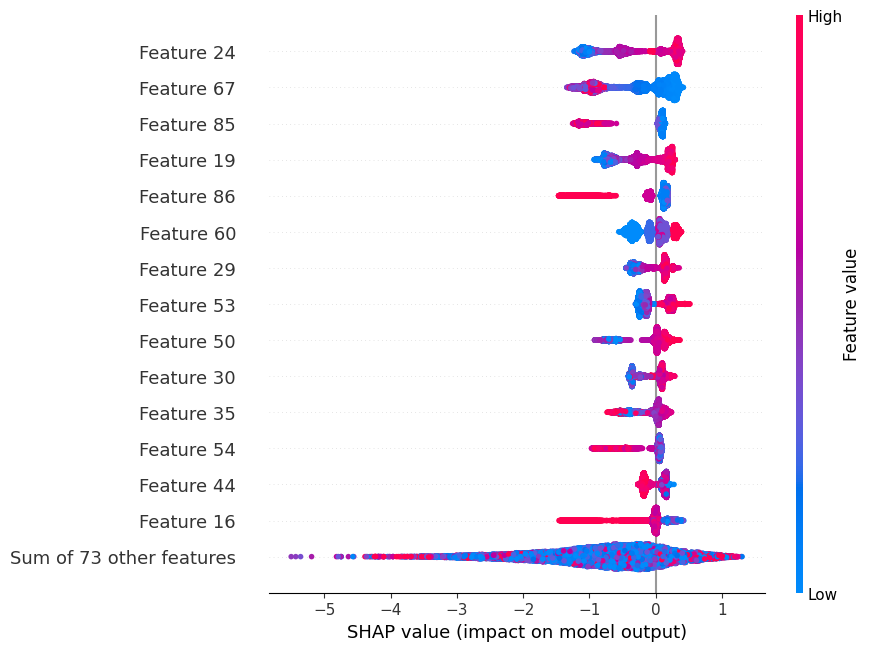

In [47]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=15)

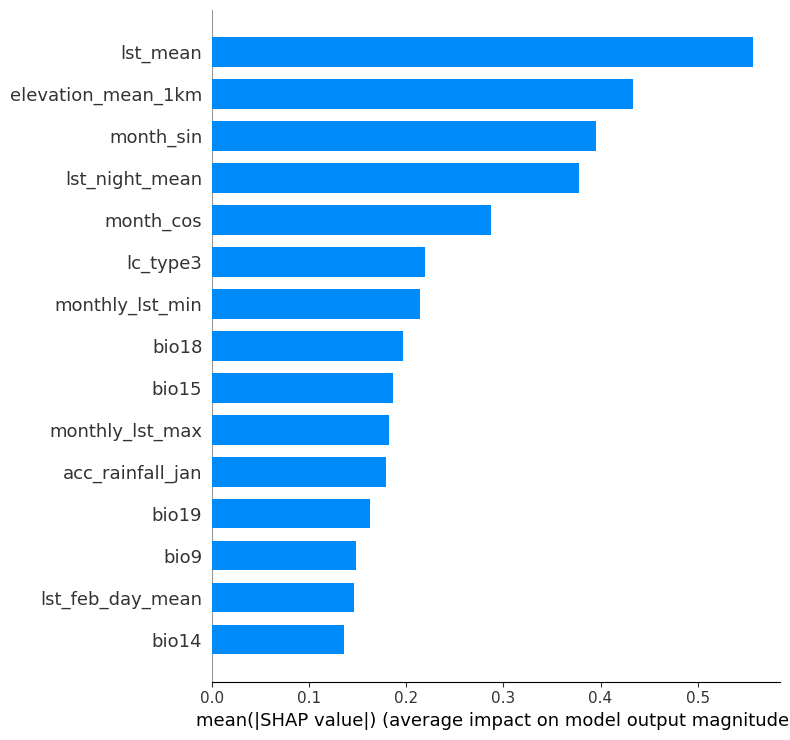

In [48]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='bar', max_display=15)

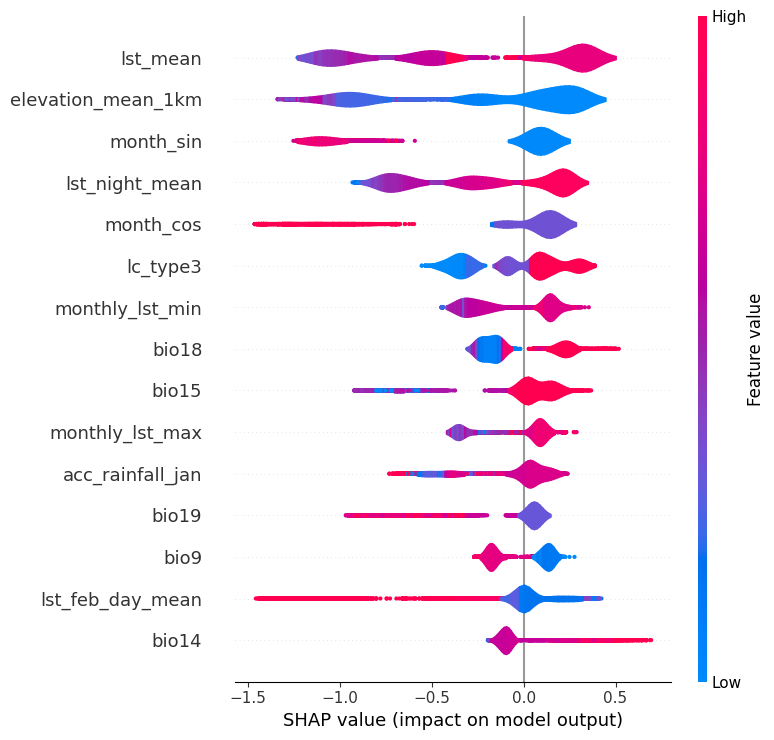

In [49]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=15)

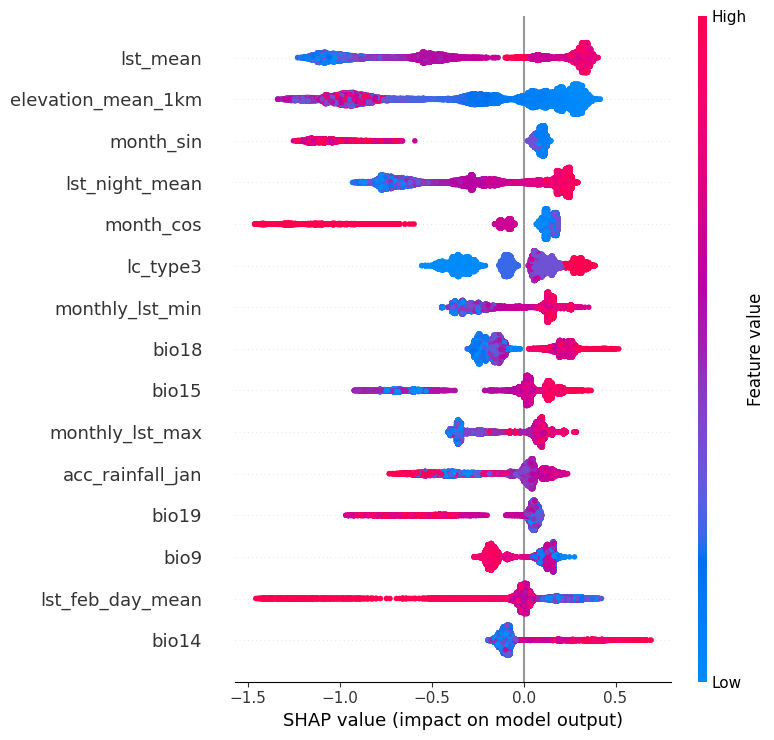

In [50]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=15)

In [55]:
shap_lim = (-2, 1)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

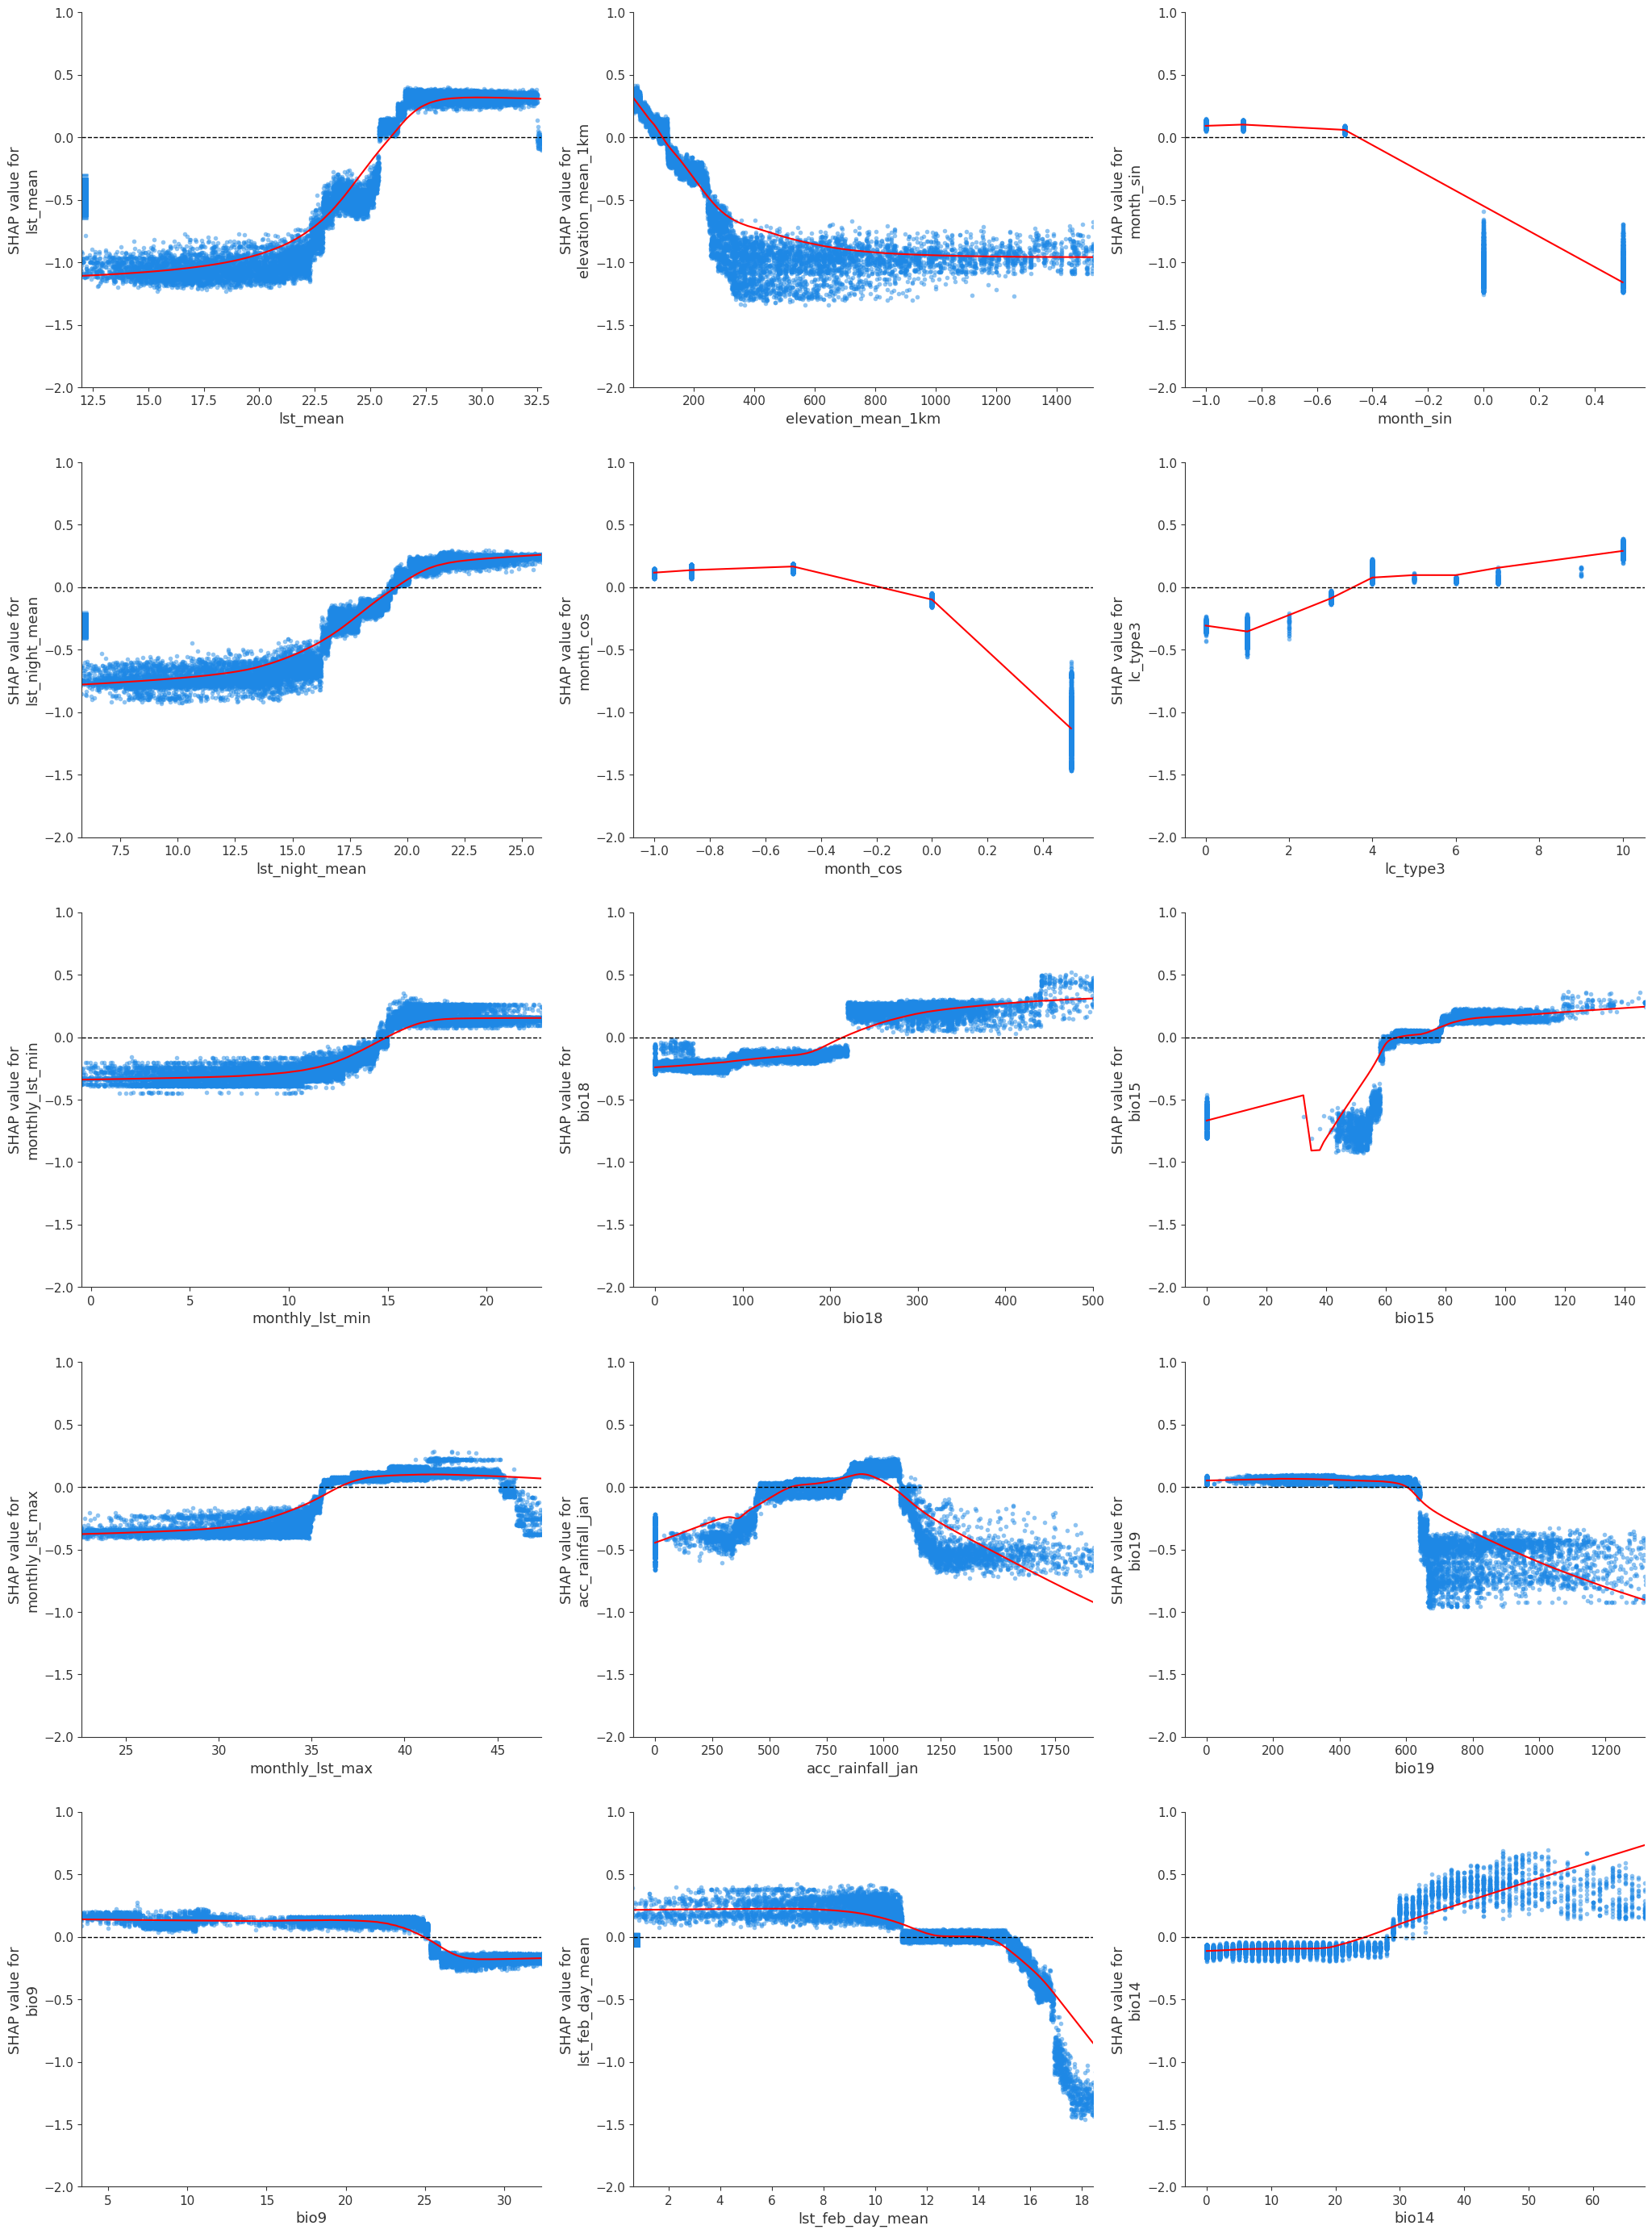

In [56]:
num_plots = 36

fig, axes = plt.subplots(5, 3, figsize=(25, 35))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:15]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=data, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax=ax, show = False)
    
    i = i+1

plt.show()

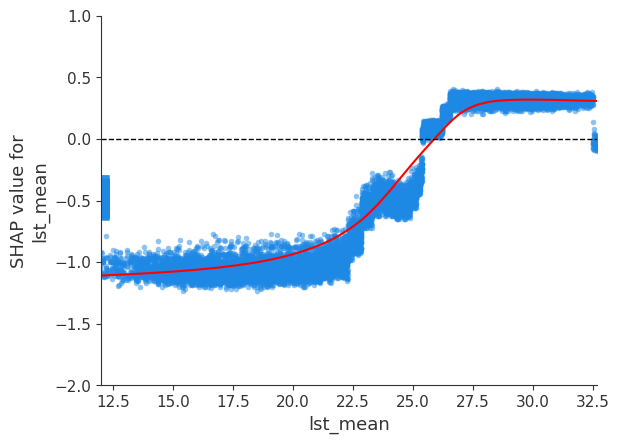

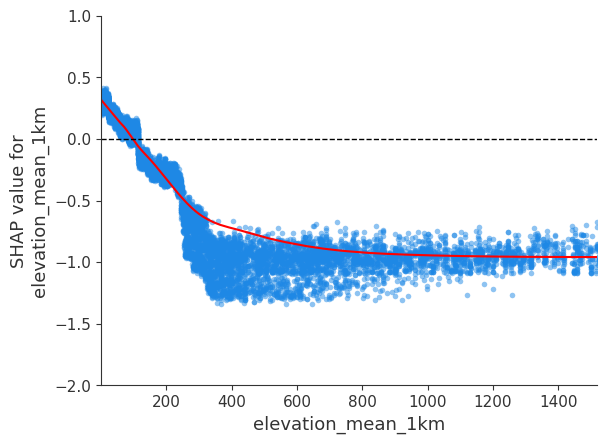

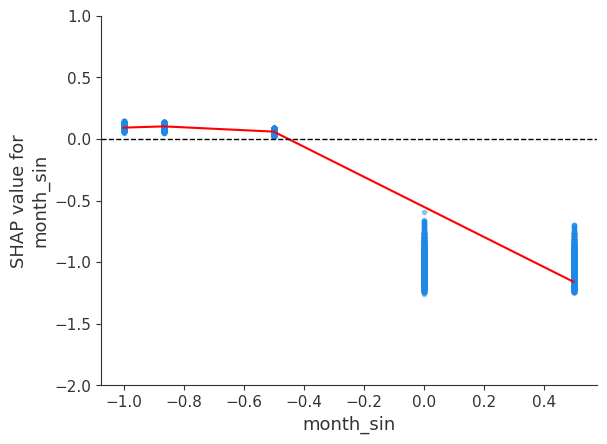

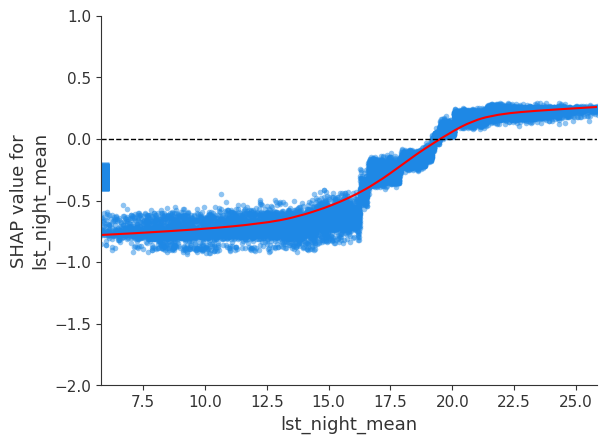

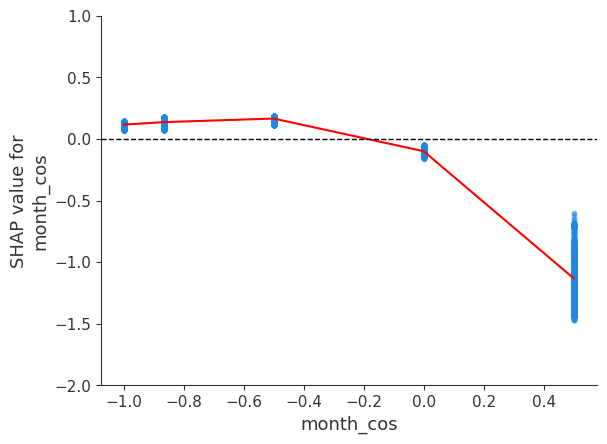

In [57]:
for ft in sorted_mean_abs_values_idx[:5]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    _,ax = plt.subplots()
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax = ax)

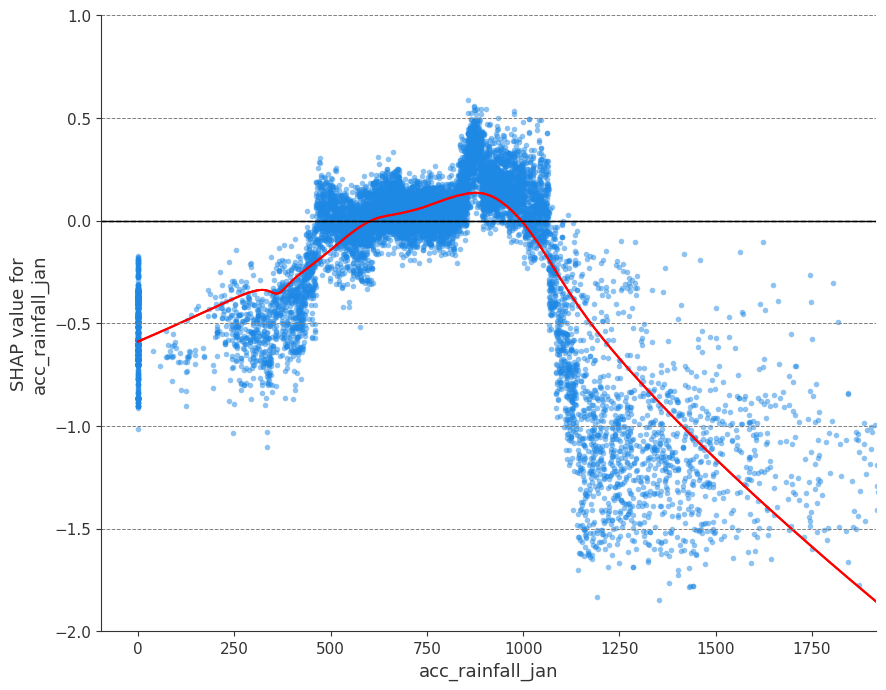

In [63]:
shap_lim = (-2, 1)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

feature = 'acc_rainfall_jan'

data = X_train
feature_names = X_train.columns

idx = np.where(X_train.columns==feature)[0][0]
x = X_train.iloc[:,idx]
y_sv = shap_values[:,idx]
lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
fig,ax = plt.subplots(figsize=(10, 8))
ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
ax.axhline(y=0, color='black', linestyle='--', lw=1)
ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
ax.axhline(y=1, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=0.5, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=0, color='black', linestyle='-', lw=1)
ax.axhline(y=-0.5, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=-1, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=-1.5, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=-2, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=-2.5, color='grey', linestyle='--', lw=0.7)
ax.axhline(y=-3, color='grey', linestyle='--', lw=0.7)
ax.set_ylim(shap_lim)
    
shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax = ax)



In [33]:
tree_shap_values_df

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_type1,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAS460,EL43,EL433,μυλοποταμου,2010,5,24.700033,35.282486,-0.052018,-0.244839,-0.027965,0.018979,0.023558,0.046888,0.182375,0.041193,0.124171,-0.043416,-0.003181,0.0,-0.064007,0.108952,0.051435,-0.001549,0.016475,-1.423840,-0.023581,-0.362698,-0.034328,-0.755097,-2.026433,-0.050284,0.133780,0.027129,0.021632,-0.492547,-1.020037,-0.016769,0.019069,-0.063823,-0.147140,-0.055414,-0.023880,-0.025138,-0.042008,-0.000951,-0.011068,0.007980,-0.002247,0.041647,-0.234914,0.108641,-0.004970,-0.352948,0.378956,-0.276782,0.125340,-0.140663,0.118170,-0.372444,-0.278175,0.015614,-0.002808,-0.119445,-0.171916,0.128158,-0.989464,-0.334438,0.009528,-0.055467,-0.064862,-0.009542,0.005273,-0.001713,0.027630,0.000793,0.058801,0.013580,0.007421,0.117357,0.240231,0.018974,0.0,0.0,0
1,AJ595,EL51,EL511,διδυμοτειχου,2010,5,26.377676,41.433334,0.099727,0.082248,-0.013188,0.024732,0.002933,0.037282,0.024907,0.039122,-0.087075,-0.016416,0.023393,0.0,-0.101053,0.054458,-0.053880,0.014435,0.012475,-2.146920,0.020483,0.379469,-0.021960,-0.099447,-1.818114,-0.050706,0.102215,-0.166079,0.044857,-0.418971,-1.128522,-0.154465,0.017171,-0.131372,0.237012,0.045450,-0.011055,-0.126544,0.157442,0.049770,-0.017570,0.002797,0.055842,0.051588,0.175470,-0.131591,0.132884,-0.294067,0.074822,-0.070882,0.112554,0.021429,0.020762,-0.132789,-0.474058,-0.211658,0.006259,0.098164,0.071088,0.112653,0.158961,-0.018152,0.012302,0.209814,-0.068293,-0.004092,-0.040499,-0.001713,-0.005730,0.000793,0.042617,0.073294,-0.217682,-0.133633,-0.028849,-0.022680,0.0,0.0,0
2,AM597,EL51,EL511,διδυμοτειχου,2010,5,26.400599,41.405838,-0.018437,0.068371,-0.019457,0.024732,0.002933,0.056807,0.024907,0.039122,0.080544,-0.011097,0.023068,0.0,-0.064179,0.054458,-0.248948,0.014435,0.015049,-2.150508,0.014920,0.387249,-0.022882,-0.355101,-1.829368,-0.050706,0.117918,-0.305504,-0.033206,-0.418394,-0.956865,-0.309237,0.017171,-0.089262,0.414239,-0.081337,-0.015758,0.025856,0.140917,0.061905,-0.011068,0.002797,0.011042,-0.307622,0.183261,0.103652,0.111961,-0.315310,-0.156299,-0.058705,0.121775,0.019737,0.021039,-0.150789,-0.468842,-0.183468,0.018958,0.048737,0.074058,0.115182,0.175370,-0.025789,0.010887,-0.000351,-0.070774,-0.003452,-0.040729,-0.001713,-0.005730,0.000793,0.020665,0.073294,-0.365971,-0.168545,-0.028849,-0.022680,0.0,0.0,0
3,BF498,EL51,EL513,ιασμου,2010,5,25.213409,41.253349,0.114610,-0.243836,0.094195,0.018979,0.034217,-0.198924,0.285522,0.040355,-0.293810,-0.015492,-0.034459,0.0,-0.116506,0.060107,-0.175661,0.021512,0.006604,-1.758334,-0.000936,0.271765,-0.345698,-0.158651,-1.848918,0.065121,0.112411,-0.212414,0.103716,-0.145442,-0.929128,-0.164904,0.021552,-0.080688,0.507044,0.044148,-0.066219,-0.021327,0.078845,0.046203,-0.011068,0.007980,-0.024539,0.049778,0.100528,0.163581,-0.007059,-0.221008,0.302517,-0.071052,0.104039,-0.076633,0.089270,-0.177556,-0.052592,-0.264984,0.021254,0.040334,-0.373403,0.025648,-0.849301,-0.252049,0.009528,0.059543,-0.068644,0.000883,0.003858,-0.001713,0.061507,0.000793,-0.386305,0.026527,-0.154329,-0.089944,-0.075273,-0.001874,0.0,0.0,0
4,BH295,EL52,EL523,κιλκις,